Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

Generate sample data (sine with Gaussian noise)

In [3]:
np.random.seed(0)

# 10 time points
X_base = np.linspace(0, 5, 10)

# True function
def f(x):
    return np.sin(x)

# Create 3 measurements per point
X = np.repeat(X_base, 3).reshape(-1, 1)
Y = f(X_base).repeat(3) + np.random.normal(0, 0.2, size=30)

Define GP

In [5]:
kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=0.1)

gp = GaussianProcessRegressor(kernel=kernel)

Learn and predict

In [6]:
gp.fit(X, Y)

X_test = np.linspace(0, 5, 100).reshape(-1, 1)
y_pred, y_std = gp.predict(X_test, return_std=True)

Visualize

In [7]:
def plotGP(X, Y, X_test, y_pred):
    plt.scatter(X, Y, color="red", label="Observations")
    plt.plot(X_test, y_pred, label="GP mean")
    plt.fill_between(
        X_test.flatten(),
        y_pred - 2*y_std,
        y_pred + 2*y_std,
        alpha=0.2,
        label="Confidence"
    )
    plt.legend()
    plt.show()

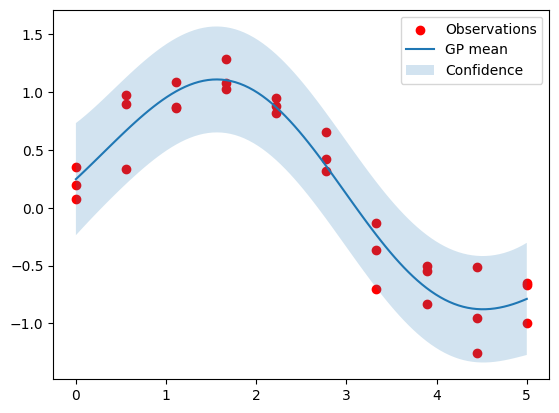

In [8]:
plotGP(X, Y, X_test, y_pred)

Aggregate measurements if we know the repetitions are just noisy measurements

In [11]:
# reshape into (n_points, 3)
Y_rep = Y.reshape(-1, 3)

# mean and variance per point
Y_mean = Y_rep.mean(axis=1)
Y_var = Y_rep.var(axis=1)

X_unique = X_base.reshape(-1, 1)

In [21]:
# Alt. 0, all as before (leads to ConvergenceWarning) 
alpha = Y_var

# Alt. 1, allow smaller noise
kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1))

# Alt. 2, fix noise level explicitly
kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=0.04, noise_level_bounds="fixed")

# Alt. 3, skip the WhiteKernel
kernel = RBF(length_scale=1.0)

# pass heteroscedastic noise via alpha
gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha)
gp.fit(X_unique, Y_mean)

X_test = np.linspace(0, 5, 100).reshape(-1, 1)
y_pred, y_std = gp.predict(X_test, return_std=True)

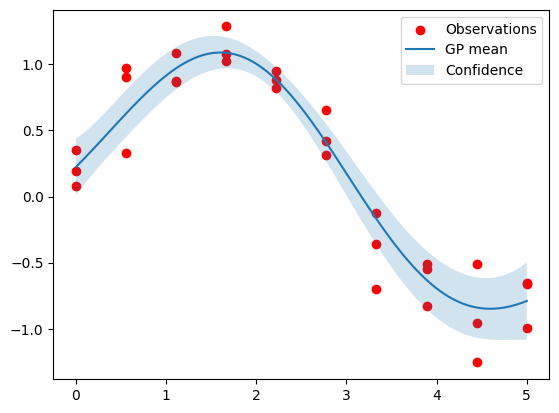

In [22]:
plotGP(X, Y, X_test, y_pred)